# 4D Dynamic Unicycle (Quadruped) Obstacle Avoidance — CBF Policy Comparison

State `(x, y, theta, v)`, control `(a, omega)` (forward acceleration + yaw rate), circular obstacle at origin.

Compares eight policies under persistent position-bias noise:
**Nominal · CBF · R-CBF-QP · Duality CBF · R-CBF (0.2) · R-CBF (1.0) · NMR-CBF · PSHR-CBF · GUARDIAN**

The dynamic unicycle has relative degree 2 in *both* `a` and `omega` through the chain `L_G h = 0`, `L_G L_f h = (cos/sin-radial, v · tangential)`. So once `v > 0` the HOCBF QP can actively steer the robot around the obstacle — mirroring the dbint2d setup.

In [1]:
import importlib
import functools as ft
import pickle
import sys
from pathlib import Path
sys.path.insert(0, '../../src')

import flax.linen as nn
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.collections import LineCollection
import numpy as np
import optax

import hj_reachability as hj
from hjnnv import hjnnvUncertaintyAwareFilter
from jaxproxqp.jaxproxqp import JaxProxQP as _JaxProxQP
from jaxproxqp.qp_problems import QPModel as _QPModel

from mrncbf.utils.jax_utils import jax_default_x32
from mrncbf.qp.min_norm_cbf import min_norm_cbf, rcbf_qp_linear, compute_rcbf_gammas

# Shared primitives — see scripts/dubins4d/dubins4d_quad.py
from dubins4d_quad import (
    AMAX, OMEGA_MAX, R_OBS, DT, T, ALPHA_HOCBF, ALPHA_QP,
    STATE_EPS, EPS_MAX, NMR_WEIGHTS_DIR,
    u_lb, u_ub,
    f, G, h_raw, B_hocbf, _cbf_ingredients,
    GOAL_MC, nom_pol_goto,
    PhiNet, phi_net,
)

jax_default_x32()

BASE_KEY        = jr.PRNGKey(0)
_mc_results_dir = Path(NMR_WEIGHTS_DIR) / 'mc_results'

Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/nrober/.pyenv/versions/pncbf_gpu/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 197, in _version_check
    version = get_version()
RuntimeError: cuDNN not found.

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/nrober/.pyenv/versions/pncbf_gpu/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 614, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/nrober/.pyenv/versions/pncbf_gpu/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 324, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/nrober/.pyenv/versions/pncbf_gpu/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 233, in _check_cuda_versions
    cudnn_version = _version_check(
  File "/home/nrober/.pyenv/v

## Dynamics and HOCBF

`f(x) = [v cos θ, v sin θ, 0, 0]ᵀ`, `G(x) = [[0,0],[0,0],[0,1],[1,0]]` (columns: `a→v̇`, `ω→θ̇`).

`h(x) = R_OBS - ||p||`, h < 0 safe. `L_G h = 0` (RD≥2). HOCBF ψ₁ = L_f h + α₀ h.

`L_G ψ₁ = (cos/sin radial component, v · tangential component)` — both nonzero when v > 0, so the QP can actively steer.

In [2]:
# Dynamics, HOCBF, and `_cbf_ingredients` are imported from `dubins4d_quad`.
x_test = jnp.array([-2.0, 0.0, 0.0, 1.0])
print(f'h at safe state:   {float(h_raw(x_test)[0]):.3f}  (expect < 0)')
print(f'psi1 at safe state: {float(B_hocbf(x_test)[0]):.3f}')
print(f'L_G B:             {(jax.jacobian(B_hocbf)(x_test) @ G(x_test))[0]}')

h at safe state:   -1.750  (expect < 0)
psi1 at safe state: -2.500
L_G B:             [1. 0.]


## Observation model and rollout infrastructure

In [3]:
def _box_bounds(xhat):
    return xhat - STATE_EPS, xhat + STATE_EPS

def _make_rollout(step_fn, goal=GOAL_MC):
    """Return a @jax.jit rollout(x0, bias) → (xs, xhats) suitable for jax.vmap."""
    @jax.jit
    def rollout(x0, bias):
        def _scan_step(carry, step_idx):
            return step_fn(carry, step_idx, goal)
        _, (xs, xhats) = jax.lax.scan(_scan_step, (x0, bias), jnp.arange(T))
        return jnp.concatenate([x0[None], xs], axis=0), xhats
    return rollout

def proj_grad_max_box(scalar_fn, lo, hi, n_restarts, n_steps, lr, key):
    x0s = lo[None] + jr.uniform(key, (n_restarts, lo.shape[0])) * (hi - lo)
    def run_one(x0):
        def step(x, _):
            g = jax.grad(scalar_fn)(x)
            return jnp.clip(x + lr * g, lo, hi), None
        x_star, _ = jax.lax.scan(step, x0, None, length=n_steps)
        return scalar_fn(x_star), x_star
    vals, xs = jax.vmap(run_one)(x0s)
    best = jnp.argmax(vals)
    return vals[best], xs[best]

ts      = np.arange(T + 1) * DT
ts_ctrl = np.arange(T) * DT

## Nominal and CBF policies

In [4]:
def _nom_step(carry, step_idx, goal):
    x, bias = carry
    xhat = x + bias
    u = nom_pol_goto(xhat, goal)
    return (x + DT*(f(x) + G(x) @ u), bias), (x, xhat)

def _cbf_step(carry, step_idx, goal):
    x, bias = carry
    xhat = x + bias
    h_B = B_hocbf(xhat)
    J_B = jax.jacobian(B_hocbf)(xhat)
    u_nom = nom_pol_goto(xhat, goal)
    u, _, _ = min_norm_cbf(ALPHA_QP, u_lb, u_ub, h_B, J_B,
                            f(xhat), G(xhat), u_nom, relax_eps2=0.1)
    return (x + DT*(f(x) + G(x) @ u), bias), (x, xhat)

In [5]:
import jax, jax.numpy as jnp                                                                                                              
print('backend:', jax.default_backend(), 'devices:', jax.devices())                                                                       
rollout_nom = _make_rollout(_nom_step)                             
X0_DEMO   = jnp.array([-1.5, 0.001, 0.0, 0.0])                                                                                            
BIAS_DEMO = jnp.zeros(4)                      
xs, _ = jax.device_get(rollout_nom(X0_DEMO, BIAS_DEMO))                                                                                   
print('Nominal OK, end:', xs[-1])

backend: gpu devices: [cuda(id=0), cuda(id=1)]
Nominal OK, end: [ 2.02837825e+00 -5.98174706e-02 -2.60030723e+00  1.27720725e-11]


## R-CBF-QP

In [6]:
N_RCBF_SAMPLES = 20

def _rcbf_step(carry, step_idx, goal):
    x, bias    = carry
    xhat       = x + bias
    samp_key   = jr.fold_in(BASE_KEY, step_idx)
    lo, hi     = _box_bounds(xhat)
    h_V_nom    = B_hocbf(xhat)
    hx_Vx_nom  = jax.jacobian(B_hocbf)(xhat)
    u_nom      = nom_pol_goto(xhat, goal)
    x_pert     = lo[None] + jr.uniform(samp_key, (N_RCBF_SAMPLES, 4)) * (hi - lo)
    h_V_pert   = jax.vmap(B_hocbf)(x_pert)
    hx_Vx_pert = jax.vmap(jax.jacobian(B_hocbf))(x_pert)
    f_pert     = jax.vmap(f)(x_pert)
    G_pert     = jax.vmap(G)(x_pert)
    u_nom_pert = jax.vmap(lambda xp: nom_pol_goto(xp, goal))(x_pert)
    gamma1, gamma2 = compute_rcbf_gammas(
        ALPHA_QP, u_lb, u_ub,
        h_V_nom, hx_Vx_nom, f(xhat), G(xhat), u_nom,
        h_V_pert, hx_Vx_pert, f_pert, G_pert, u_nom_pert, n_grid=50)
    u, _, _ = rcbf_qp_linear(ALPHA_QP, u_lb, u_ub, h_V_nom, hx_Vx_nom,
                              f(xhat), G(xhat), u_nom,
                              gamma1=gamma1, gamma2=gamma2, relax_eps2=0.1)
    return (x + DT*(f(x) + G(x) @ u), bias), (x, xhat)

## Duality CBF

Builds a polytope over-approximation of the 3D image set
`{ [LGψ₁[0](x), LGψ₁[1](x), Lfψ₁(x)+α·ψ₁(x)] : x ∈ uncertainty box }`
via Fibonacci-sphere support functions, then solves a QP using LP duality.

NU=2 → image lives on S² (same as dbint2d).

In [7]:
N_PLANES_DUAL = 16
_golden    = (1 + np.sqrt(5)) / 2
_ks        = np.arange(N_PLANES_DUAL)
_theta_fib = np.arccos(1 - 2*(_ks + 0.5) / N_PLANES_DUAL)
_phi_fib   = 2*np.pi*_ks / _golden
_DUAL_DIRS = np.stack([
    np.sin(_theta_fib)*np.cos(_phi_fib),
    np.sin(_theta_fib)*np.sin(_phi_fib),
    np.cos(_theta_fib),
], axis=1)   # (N_PLANES_DUAL, 3) — Fibonacci sphere directions on S²

def _image_fn(x, alpha=ALPHA_HOCBF):
    h_B, Lf_B, LG_B = _cbf_ingredients(x, alpha)
    return jnp.array([LG_B[0, 0], LG_B[0, 1], Lf_B[0] + ALPHA_QP*h_B[0]])

def _duality_cbf_qp(C_poly, d_poly, u_nom, relax_eps=0.1, penalty=10.0):
    """Duality-based CBF QP for NU=2."""
    N = C_poly.shape[0]
    n = N + 3

    H = jnp.zeros((n, n))
    H = H.at[N,   N  ].set(1.0)
    H = H.at[N+1, N+1].set(1.0)
    H = H.at[N+2, N+2].set(penalty)

    g = jnp.zeros(n)
    g = g.at[N  ].set(-u_nom[0])
    g = g.at[N+1].set(-u_nom[1])
    g = g.at[N+2].set(penalty * relax_eps)

    A_eq = jnp.zeros((3, n))
    A_eq = A_eq.at[:, :N].set(C_poly.T)
    A_eq = A_eq.at[0, N  ].set(-1.0)
    A_eq = A_eq.at[1, N+1].set(-1.0)
    b_eq = jnp.array([0.0, 0.0, 1.0])

    C_ineq = jnp.zeros((1, n))
    C_ineq = C_ineq.at[0, :N].set(d_poly)
    C_ineq = C_ineq.at[0, N+2].set(-1.0)
    l_ineq = jnp.array([-1e8])
    u_ineq = jnp.array([0.0])

    l_box = jnp.concatenate([jnp.zeros(N), u_lb, jnp.array([-relax_eps])])
    u_box = jnp.concatenate([jnp.full(N, 1e8), u_ub, jnp.array([1e8])])

    qp  = _QPModel(H, g, A_eq, C_ineq, b_eq, u_ineq, l_ineq, u_box, l_box)
    sol = _JaxProxQP(qp, _JaxProxQP.Settings.default()).solve()
    return sol.x[N:N+2], sol.x[N+2], sol

def _duality_step(carry, step_idx, goal):
    x, bias  = carry
    xhat     = x + bias
    lo, hi   = _box_bounds(xhat)
    u_nom    = nom_pol_goto(xhat, goal)
    opt_key  = jr.fold_in(BASE_KEY, step_idx)
    all_keys = jr.split(opt_key, N_PLANES_DUAL)

    def _support_one(d_vec, k_j):
        val, _ = proj_grad_max_box(
            lambda xi: d_vec @ _image_fn(xi), lo, hi,
            n_restarts=2, n_steps=15, lr=0.05, key=k_j)
        return val

    d_poly = jax.vmap(_support_one)(_DUAL_DIRS, all_keys)
    u, _, _ = _duality_cbf_qp(_DUAL_DIRS, d_poly, u_nom)
    return (x + DT*(f(x) + G(x) @ u), bias), (x, xhat)

## R-CBF with fixed γ

In [8]:
def _make_rcbf_fixed_step(gamma_val):
    def _step(carry, step_idx, goal):
        x, bias   = carry
        xhat      = x + bias
        h_V_nom   = B_hocbf(xhat)
        hx_Vx_nom = jax.jacobian(B_hocbf)(xhat)
        u_nom     = nom_pol_goto(xhat, goal)
        u, _, _   = rcbf_qp_linear(ALPHA_QP, u_lb, u_ub, h_V_nom, hx_Vx_nom,
                                    f(xhat), G(xhat), u_nom,
                                    gamma1=gamma_val, gamma2=gamma_val, relax_eps2=0.1)
        return (x + DT*(f(x) + G(x) @ u), bias), (x, xhat)
    return _step

## NMR-CBF — Learning φ

`φ(x̂, ε) ≥ max_{x∈[x̂-ε, x̂+ε]}[Lfψ₁(x)+α·ψ₁(x)] - [Lfψ₁(x̂)+α·ψ₁(x̂)]`

Network input is `(x̂, ε)` concatenated — trains across `ε ~ Uniform[0, EPS_MAX]` so
the same weights generalise to any noise level up to `EPS_MAX`.  Weights saved to
`NMR_WEIGHTS_DIR/phi_params.pkl`; loaded automatically if present.

In [9]:
PHI_MAX = 8.0   # cap labels against outliers near the obstacle boundary

@ft.partial(jax.jit, static_argnames=('n_restarts', 'n_steps'))
def phi_true_fn(xhat, eps, key, n_restarts=8, n_steps=60, lr=0.05):
    """φ_i(x̂, ε) = max_{x∈[x̂-ε, x̂+ε]} (Lfψ₁+αψ₁)(x) - (Lfψ₁+αψ₁)(x̂), clipped ≥ 0."""
    lo     = xhat - eps
    hi     = xhat + eps
    h_nom  = B_hocbf(xhat)
    Lf_nom = jax.jacobian(B_hocbf)(xhat) @ f(xhat)
    def worst_i(i, k):
        _, x_wc = proj_grad_max_box(
            lambda x: (jax.jacobian(B_hocbf)(x) @ f(x) + ALPHA_QP * B_hocbf(x))[i],
            lo, hi, n_restarts, n_steps, lr, k)
        h_wc  = B_hocbf(x_wc)[i]
        Lf_wc = (jax.jacobian(B_hocbf)(x_wc) @ f(x_wc))[i]
        delta = (Lf_wc + ALPHA_QP * h_wc) - (Lf_nom[i] + ALPHA_QP * h_nom[i])
        return jnp.clip(delta, 0.0, PHI_MAX)
    keys = jr.split(key, 1)
    return jax.vmap(worst_i)(jnp.arange(1), keys)   # (1,)

# `PhiNet` and `phi_net` are imported from `dubins4d_quad`.

_nmr_dir           = Path(NMR_WEIGHTS_DIR)
_nmr_pretrain_file = _nmr_dir / 'phi_params.pkl'

# ── Load or train pretrained weights ─────────────────────────────────────────
if _nmr_pretrain_file.exists():
    with open(_nmr_pretrain_file, 'rb') as _f:
        _phi_params_pretrain = pickle.load(_f)
    print(f'Loaded NMR-CBF (pretrain) weights from {_nmr_pretrain_file}')
else:
    _phi_params_pretrain = phi_net.init(jr.PRNGKey(0), jnp.zeros(4), jnp.zeros(4))['params']
    n_params   = sum(p.size for p in jax.tree_util.tree_leaves(_phi_params_pretrain))
    print(f'Training PhiNet ({n_params} params, input=8, output=1)...')

    # Sample states (x, y, theta, v) outside the obstacle.
    x_lo = jnp.array([-3., -3., -jnp.pi,  0.0])
    x_hi = jnp.array([ 3.,  3.,  jnp.pi,  1.5])
    N_TRAIN, N_TEST = 20000, 5000
    rng_phi = jr.PRNGKey(7)
    rng_phi, rng_tr, rng_te, rng_eps_tr, rng_eps_te = jr.split(rng_phi, 5)

    def _outside(xh):
        return jnp.sqrt(xh[0]**2 + xh[1]**2) > R_OBS + 0.1

    cands_tr   = x_lo + jr.uniform(rng_tr, (N_TRAIN * 2, 4)) * (x_hi - x_lo)
    cands_te   = x_lo + jr.uniform(rng_te, (N_TEST  * 2, 4)) * (x_hi - x_lo)
    xhat_train = cands_tr[jax.vmap(_outside)(cands_tr)][:N_TRAIN]
    xhat_test  = cands_te[jax.vmap(_outside)(cands_te)][:N_TEST]

    # eps sampled per-sample from Uniform[0, EPS_MAX] — network generalises across noise levels
    eps_train = jr.uniform(rng_eps_tr, (N_TRAIN, 4)) * EPS_MAX
    eps_test  = jr.uniform(rng_eps_te, (N_TEST,  4)) * EPS_MAX

    keys_tr = jr.split(jr.PRNGKey(1), N_TRAIN)
    keys_te = jr.split(jr.PRNGKey(2), N_TEST)

    print('  Computing phi_true (training)...')
    phi_train = jax.vmap(phi_true_fn)(xhat_train, eps_train, keys_tr)
    print('  Computing phi_true (test)...')
    phi_test  = jax.vmap(phi_true_fn)(xhat_test,  eps_test,  keys_te)
    print(f'  phi: mean={float(jnp.mean(phi_train)):.4f}  '
          f'max={float(jnp.max(phi_train)):.4f}  min={float(jnp.min(phi_train)):.4f}')

    optimizer = optax.adam(3e-3)
    opt_state = optimizer.init(_phi_params_pretrain)

    @jax.jit
    def train_step(params, opt_state, xhat_b, eps_b, phi_b):
        def loss_fn(p):
            pred = jax.vmap(lambda x, e: phi_net.apply({'params': p}, x, e))(xhat_b, eps_b)
            return jnp.mean((pred - phi_b) ** 2)
        loss, grads = jax.value_and_grad(loss_fn)(params)
        updates, new_opt = optimizer.update(grads, opt_state, params)
        return optax.apply_updates(params, updates), new_opt, loss

    rng_ep = jr.PRNGKey(42)
    for epoch in range(400):
        rng_ep, rng_s = jr.split(rng_ep)
        perm = jr.permutation(rng_s, N_TRAIN)
        for b in range(0, N_TRAIN, 256):
            idx = perm[b : b + 256]
            _phi_params_pretrain, opt_state, ep_loss = train_step(
                _phi_params_pretrain, opt_state, xhat_train[idx], eps_train[idx], phi_train[idx])
        if (epoch + 1) % 100 == 0:
            pred_val = jax.vmap(lambda x, e: phi_net.apply({'params': _phi_params_pretrain}, x, e))(
                xhat_test, eps_test)
            val_mse = float(jnp.mean((pred_val - phi_test) ** 2))
            print(f'  Epoch {epoch+1:3d}  train_loss={ep_loss:.3e}  val_mse={val_mse:.3e}')

    _nmr_dir.mkdir(parents=True, exist_ok=True)
    with open(_nmr_pretrain_file, 'wb') as _f:
        pickle.dump(_phi_params_pretrain, _f)
    print(f'Saved NMR-CBF (pretrain) weights to {_nmr_pretrain_file}')

Loaded NMR-CBF (pretrain) weights from /home/nrober/code/pncbf/pncbf/runs/nmr_cbf_dubins4d/policies/obs0.25/phi_params.pkl


In [10]:
def _make_nmr_step(phi_params_frozen):
    def _nmr_step(carry, step_idx, goal):
        x, bias   = carry
        xhat      = x + bias
        phi       = phi_net.apply({'params': phi_params_frozen}, xhat, STATE_EPS)
        h_B       = B_hocbf(xhat)
        J_B       = jax.jacobian(B_hocbf)(xhat)
        u_nom     = nom_pol_goto(xhat, goal)
        u, _, _   = min_norm_cbf(ALPHA_QP, u_lb, u_ub, h_B + phi/ALPHA_QP, J_B,
                                  f(xhat), G(xhat), u_nom, relax_eps2=0.1)
        return (x + DT*(f(x) + G(x) @ u), bias), (x, xhat)
    return _nmr_step

_nmr_pretrain_step = _make_nmr_step(_phi_params_pretrain)

## PSHR-CBF (φ-oracle) — worst-case Lf+αh, nominal LG

Same QP as NMR-CBF but computes φ exactly at runtime via projected-gradient ascent
instead of using a learned network.

In [11]:
def _lfhwc_step(carry, step_idx, goal):
    x, bias   = carry
    xhat      = x + bias
    lo, hi    = _box_bounds(xhat)
    u_nom     = nom_pol_goto(xhat, goal)
    opt_key   = jr.fold_in(BASE_KEY, step_idx)

    h_nom  = B_hocbf(xhat)
    J_nom  = jax.jacobian(B_hocbf)(xhat)
    Lf_nom = J_nom @ f(xhat)

    nh   = h_nom.shape[0]
    keys = jr.split(opt_key, nh)

    def worst_i(i, k):
        _, x_wc = proj_grad_max_box(
            lambda xi: (jax.jacobian(B_hocbf)(xi) @ f(xi) + ALPHA_QP * B_hocbf(xi))[i],
            lo, hi, n_restarts=4, n_steps=25, lr=0.05, key=k)
        h_wc_i  = B_hocbf(x_wc)[i]
        Lf_wc_i = (jax.jacobian(B_hocbf)(x_wc) @ f(x_wc))[i]
        return h_wc_i, Lf_wc_i

    h_wc, Lf_wc = jax.vmap(worst_i)(jnp.arange(nh), keys)
    phi_oracle = (Lf_wc + ALPHA_QP * h_wc) - (Lf_nom + ALPHA_QP * h_nom)
    u, _, _ = min_norm_cbf(ALPHA_QP, u_lb, u_ub, h_nom + phi_oracle / ALPHA_QP, J_nom,
                            f(xhat), G(xhat), u_nom, relax_eps2=0.1)
    return (x + DT * (f(x) + G(x) @ u), bias), (x, xhat)

## GUARDIAN

4D HJ grid (40⁴ ≈ 2.56M points) over (x, y, θ, v).  The HJ dynamics class wraps the
unicycle into the `hj_reachability` interface, with a per-dim disturbance box.

In [12]:
class Dubins4DHJ(hj.ControlAndDisturbanceAffineDynamics):
    def __init__(self, amax=AMAX, omega_max=OMEGA_MAX, max_disturbance=1e-1, dt=DT,
                 control_mode='max', disturbance_mode='min'):
        super().__init__(
            control_space=hj.sets.Box(
                np.array([-amax, -omega_max]), np.array([amax, omega_max])),
            disturbance_space=hj.sets.Box(
                np.array([-max_disturbance]*4), np.array([max_disturbance]*4)),
            control_mode=control_mode, disturbance_mode=disturbance_mode)
        self._amax = amax
        self._omega_max = omega_max
        self.dt = dt

    def open_loop_dynamics(self, state, time):
        x, y, theta, v = state
        return jnp.array([v * jnp.cos(theta), v * jnp.sin(theta), 0.0, 0.0])
    def control_jacobian(self, state, time):
        # Columns: a -> v_dot (row 3), omega -> theta_dot (row 2)
        return jnp.array([[0., 0.], [0., 0.], [0., 1.], [1., 0.]])
    def disturbance_jacobian(self, state, time):
        return jnp.eye(4)
    def step(self, state, control, disturbance, time=0.):
        return state + self(state, control, disturbance, time) * self.dt

N_GRID      = 40
hj_dynamics = Dubins4DHJ(amax=AMAX, omega_max=OMEGA_MAX)
hj_grid     = hj.Grid.from_lattice_parameters_and_boundary_conditions(
    hj.sets.Box(np.array([-3., -3., -np.pi, 0.0]), np.array([3., 3., np.pi, 1.5])),
    (N_GRID,)*4,
    periodic_dims=(2,))
hj_initial_values = -R_OBS**2 + hj_grid.states[..., 0]**2 + hj_grid.states[..., 1]**2

guardian_filter = hjnnvUncertaintyAwareFilter(
    dynamics=hj_dynamics,
    pred_model=lambda obs: obs,
    grid=hj_grid,
    initial_values=hj_initial_values,
    num_controls=10,
    num_disturbances=3,
)
print('GUARDIAN filter initialised.')

100%|##########| 10.0000/10.0 [00:09<00:00,  1.09sim_s/s]


GUARDIAN filter initialised.


## Safety set visualisation — XY slice at θ=0, v=1

Plot `h(x)` and `ψ₁(x)` over the XY plane with the HJ backward-reachable tube
zero-level-set overlaid as a ground-truth safety boundary.

In [30]:
THETA_SLICE = 0.0
V_SLICE     = 1.0

# --- HJ backward reachable tube (coarser grid for speed) ---
N_VIZ_GRID = 60
hj_grid_viz = hj.Grid.from_lattice_parameters_and_boundary_conditions(
    hj.sets.Box(np.array([-3., -3., -np.pi, 0.0]), np.array([3., 3., np.pi, 1.5])),
    (N_VIZ_GRID,) * 4,
    periodic_dims=(2,))
hj_initial_viz = -R_OBS**2 + hj_grid_viz.states[..., 0]**2 + hj_grid_viz.states[..., 1]**2

print(f'Computing HJ backward reachable tube on {N_VIZ_GRID}^4 grid...')
_solver_settings = hj.SolverSettings.with_accuracy(
    'high', hamiltonian_postprocessor=hj.solver.backwards_reachable_tube)
hj_target_viz = hj.step(_solver_settings, hj_dynamics, hj_grid_viz, 0.0, hj_initial_viz, -5.0)
print('Done.')

# Slice at (theta, v) — grid dim order: x=0, y=1, theta=2, v=3
_cvecs   = hj_grid_viz.coordinate_vectors
_th_idx  = int(np.argmin(np.abs(np.array(_cvecs[2]) - THETA_SLICE)))
_v_idx   = int(np.argmin(np.abs(np.array(_cvecs[3]) - V_SLICE)))
hj_slice = np.array(hj_target_viz[:, :, _th_idx, _v_idx])   # (N_x, N_y)
_x_c     = np.array(_cvecs[0])
_y_c     = np.array(_cvecs[1])
print(f'HJ slice shape {hj_slice.shape}  '
      f'theta≈{float(_cvecs[2][_th_idx]):.2f}  v≈{float(_cvecs[3][_v_idx]):.2f}')

# --- h and ψ₁ on a fine XY mesh ---
N_VIZ = 80
x_g, y_g   = np.linspace(-2.5, 2.5, N_VIZ), np.linspace(-2.5, 2.5, N_VIZ)
X_G, Y_G   = np.meshgrid(x_g, y_g)
x_viz = jnp.stack([X_G.ravel(),
                   Y_G.ravel(),
                   jnp.full(N_VIZ**2, THETA_SLICE),
                   jnp.full(N_VIZ**2, V_SLICE)], axis=1)
h_viz = np.array(jax.vmap(h_raw)(x_viz)[:, 0].reshape(N_VIZ, N_VIZ))
B_viz = np.array(jax.vmap(B_hocbf)(x_viz)[:, 0].reshape(N_VIZ, N_VIZ))
print(f'h ∈ [{h_viz.min():.2f}, {h_viz.max():.2f}]   '
      f'ψ₁ ∈ [{B_viz.min():.2f}, {B_viz.max():.2f}]')

Computing HJ backward reachable tube on 60^4 grid...


100%|##########|  5.0000/5.0 [01:05<00:00, 13.19s/sim_s]

Done.
HJ slice shape (60, 60)  theta≈0.00  v≈0.99
h ∈ [-3.29, 0.21]   ψ₁ ∈ [-7.28, 1.25]


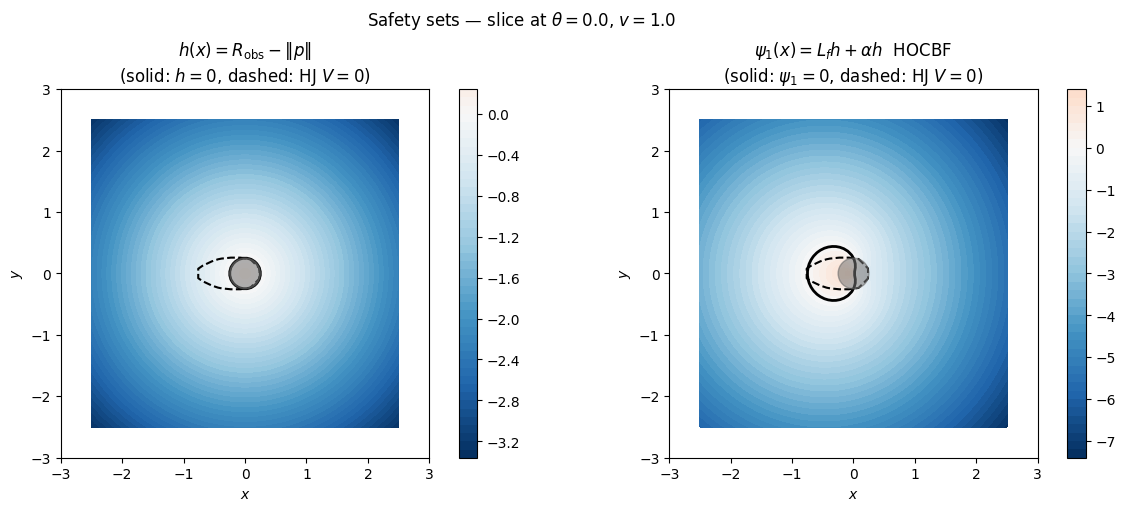

In [14]:
fig_viz, axes_viz = plt.subplots(1, 2, figsize=(12, 5), layout='constrained')

_titles = [
    r'$h(x) = R_{\rm obs} - \|p\|$'
    f'\n(solid: $h=0$, dashed: HJ $V=0$)',
    r'$\psi_1(x) = L_f h + \alpha h$  HOCBF'
    f'\n(solid: $\psi_1=0$, dashed: HJ $V=0$)',
]

for ax, val_grid, title in zip(axes_viz, [h_viz, B_viz], _titles):
    lim = float(np.abs(val_grid).max()) * 1.01
    cf  = ax.contourf(x_g, y_g, val_grid, levels=50,
                      cmap='RdBu_r', vmin=-lim, vmax=lim)
    ax.contour(x_g, y_g, val_grid, levels=[0.0], colors='k', linewidths=2.0)
    ax.contour(_x_c, _y_c, hj_slice.T, levels=[0.0],
               colors='k', linewidths=1.5, linestyles='--')
    ax.add_patch(Circle((0, 0), R_OBS,
                        facecolor='0.45', edgecolor='0.4', alpha=0.55, zorder=3))
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$y$')
    ax.set_aspect('equal')
    ax.set_title(title)
    plt.colorbar(cf, ax=ax)

fig_viz.suptitle(
    rf'Safety sets — slice at $\theta = {THETA_SLICE}$, $v = {V_SLICE}$')
plt.show()

In [31]:
def _guardian_step(carry, step_idx, goal):
    x, bias      = carry
    xhat         = x + bias
    lo, hi       = _box_bounds(xhat)
    state_bounds = hj.sets.Box(lo, hi)
    u_nom        = nom_pol_goto(xhat, goal)
    _, u_star, _, val_filter, _, _ = guardian_filter.ua_filter_max_val(
        u_nom, state_bounds, num_states=5)
    u = jnp.where(val_filter < 0.0, u_star, u_nom)
    return (x + DT*(f(x) + G(x) @ u), bias), (x, xhat)

## Demo rollout — single trajectory

In [33]:
# print('Precompiling rollouts...')
# for name, fn in _ALL_ROLLOUTS:                                                                                                            
#     print(f'  {name:<16} ...', end='', flush=True)
#     try:                                                                                                                                  
#         jax.block_until_ready(fn(X0_DEMO, BIAS_DEMO))
#         print(' OK')                                                                                                                      
#     except Exception as e:
#         print(f' FAILED: {type(e).__name__}: {e}')                                                                                        
#         raise


# Named rollout functions — goal captured in closure, signature (x0, bias) for vmap
rollout_nom          = _make_rollout(_nom_step)
rollout_cbf          = _make_rollout(_cbf_step)
rollout_rcbf         = _make_rollout(_rcbf_step)
rollout_duality      = _make_rollout(_duality_step)
rollout_rcbf_02      = _make_rollout(_make_rcbf_fixed_step(0.2))
rollout_rcbf_10      = _make_rollout(_make_rcbf_fixed_step(1.0))
rollout_nmr_pretrain = _make_rollout(_nmr_pretrain_step)
rollout_guardian     = _make_rollout(_guardian_step)
rollout_lfhwc        = _make_rollout(_lfhwc_step)

_ALL_ROLLOUTS = [
    ('Nominal',     rollout_nom),
    ('CBF',         rollout_cbf),
    ('R-CBF-QP',    rollout_rcbf),
    ('Duality CBF', rollout_duality),
    ('R-CBF (0.2)', rollout_rcbf_02),
    ('R-CBF (1.0)', rollout_rcbf_10),
    ('NMR-CBF',     rollout_nmr_pretrain),
    ('PSHR-CBF',    rollout_lfhwc),
    ('GUARDIAN',    rollout_guardian),
]

X0_DEMO   = jnp.array([-1.5, 0.2, 0.0, 0.0])
# Bias position towards obstacle to test safety
BIAS_DEMO = jnp.array([STATE_EPS[0], -STATE_EPS[1], STATE_EPS[2], -STATE_EPS[3]])

# --- Precompile all rollouts so MC timing is fair ---
print('Precompiling rollouts...')
for name, fn in _ALL_ROLLOUTS:
    jax.block_until_ready(fn(X0_DEMO, BIAS_DEMO))
    print(f'  {name:<16}  compiled')

# --- Demo run ---
print('\nDemo rollout (obstacle violated?):')
results = {}
for name, fn in _ALL_ROLLOUTS:
    xs, xhats = jax.device_get(fn(X0_DEMO, BIAS_DEMO))
    results[name] = dict(xs=xs, xhats=xhats)
    viol = bool(np.any(xs[:, 0]**2 + xs[:, 1]**2 < R_OBS**2 - 1e-3))
    print(f'  {name:<16}  {viol}')

Precompiling rollouts...
  Nominal           compiled
  CBF               compiled
  R-CBF-QP          compiled
  Duality CBF       compiled
  R-CBF (0.2)       compiled
  R-CBF (1.0)       compiled
  NMR-CBF           compiled
  PSHR-CBF          compiled
  GUARDIAN          compiled

Demo rollout (obstacle violated?):
  Nominal           True
  CBF               False
  R-CBF-QP          False
  Duality CBF       False
  R-CBF (0.2)       False
  R-CBF (1.0)       False
  NMR-CBF           False
  PSHR-CBF          False
  GUARDIAN          True


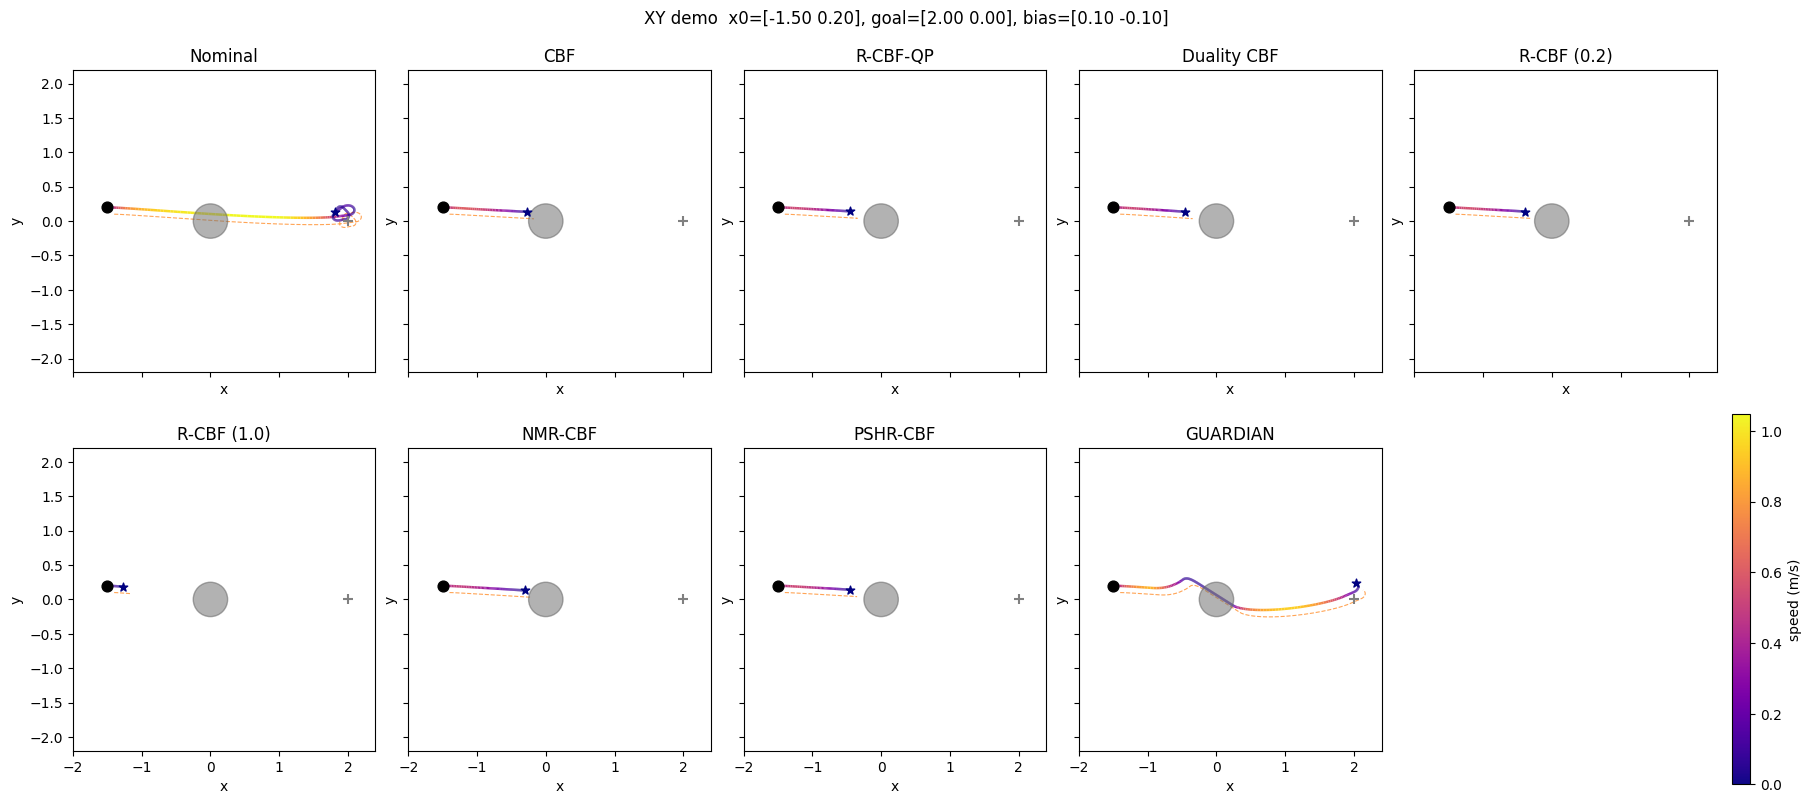

: 

In [ ]:
_XLIM = (-2.0, 2.4)
_YLIM = (-2.2, 2.2)

fig, axes = plt.subplots(2, 5, figsize=(18, 8), layout='constrained',
                          sharex=True, sharey=True)
axes = axes.flatten()

# Speed at each timestep = |v| (state[3]); vmax clipped to the visible window.
_all_speeds = []
_vmax_in_window = []
for d in results.values():
    xs    = d['xs']
    speed = np.abs(xs[:, 3])
    _all_speeds.append(speed)
    in_window = (np.abs(xs[:,0]) <= _XLIM[1]) & (np.abs(xs[:,1]) <= _YLIM[1])
    if in_window.any():
        _vmax_in_window.append(float(speed[in_window].max()))

_speed_norm = plt.Normalize(0, max(_vmax_in_window) if _vmax_in_window else 1.0)

lc_last = None
for ax, (name, d), speed in zip(axes, results.items(), _all_speeds):
    xs, xhats = d['xs'], d['xhats']
    pts  = np.stack([xs[:, 0], xs[:, 1]], axis=1).reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    lc   = LineCollection(segs, cmap='plasma', norm=_speed_norm, lw=1.8, zorder=3)
    lc.set_array((speed[:-1] + speed[1:]) / 2)
    ax.add_collection(lc)
    ax.plot(xhats[:, 0], xhats[:, 1], color='C1', lw=0.8, ls='--', alpha=0.7)
    ax.scatter(xs[0, 0],  xs[0, 1],  s=60, color='k',    zorder=6)
    ax.scatter(xs[-1, 0], xs[-1, 1], s=40, color='navy', marker='*', zorder=6)
    ax.scatter(*GOAL_MC[:2], s=50, color='gray', marker='+', zorder=5)
    ax.add_patch(Circle((0, 0), R_OBS, facecolor='0.45', edgecolor='0.4', alpha=0.55, zorder=4))
    ax.set_xlim(*_XLIM); ax.set_ylim(*_YLIM); ax.set_aspect('equal')
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_title(name)
    lc_last = lc

# Hide any unused axes
for ax in axes[len(results):]:
    ax.set_visible(False)

fig.colorbar(lc_last, ax=axes[-1], label='speed (m/s)')
_x0_xy   = [float(X0_DEMO[0]),   float(X0_DEMO[1])]
_bias_xy = [float(BIAS_DEMO[0]), float(BIAS_DEMO[1])]
fig.suptitle(
    f"XY demo  x0={np.array2string(np.array(_x0_xy), formatter={'float_kind':lambda x: f'{x:.2f}'})}, "
    f"goal={np.array2string(np.array(GOAL_MC[:2]), formatter={'float_kind':lambda x: f'{x:.2f}'})}, "
    f"bias={np.array2string(np.array(_bias_xy), formatter={'float_kind':lambda x: f'{x:.2f}'})}"
)
plt.show()

## Monte Carlo safety evaluation

In [ ]:
GOAL_TOL  = 0.1   # metres — final position tolerance
VEL_TOL   = 0.1   # m/s   — final speed tolerance
N_MC      = 1_000
# row0: [x_min, y_min]; row1: [x_max, y_max]
MC_BOUNDS = np.array([[-2.5, -1.5], [-0.25, 1.5]])

_eps_x_val      = float(STATE_EPS[0])
_mc_cache_file  = _mc_results_dir / f'mc_eps_{_eps_x_val:.3f}.pkl'

# ICs always generated from the same seed so they match cached violation arrays
rng_mc = jr.PRNGKey(42)
rng_mc, rng_ic, rng_bias = jr.split(rng_mc, 3)
# (x0, y0) uniform; theta0=0, v0=0
x0pos  = jr.uniform(rng_ic,   (N_MC, 2), minval=MC_BOUNDS[0], maxval=MC_BOUNDS[1])
x0s    = jnp.stack([x0pos[:, 0], x0pos[:, 1],
                    jnp.zeros(N_MC), jnp.zeros(N_MC)], axis=1)
biases = jr.uniform(rng_bias, (N_MC, 4), minval=-STATE_EPS, maxval=STATE_EPS)
print(f'x0s {x0s.shape}  biases {biases.shape}')

mc_results     = {}
mc_goals       = {}
mc_viols       = {}
mc_reached     = {}
mc_reach_times = {}

_loaded_from_cache = False
if _mc_cache_file.exists():
    with open(_mc_cache_file, 'rb') as _f:
        _cached = pickle.load(_f)
    if 'violation_array' in _cached and 'reached_array' in _cached:
        print(f'Loading cached MC results from {_mc_cache_file}')
        N_MC       = _cached['N_MC']
        mc_viols       = {k: np.array(v, dtype=bool) for k, v in _cached['violation_array'].items()}
        mc_reached     = {k: np.array(v, dtype=bool) for k, v in _cached['reached_array'].items()}
        mc_reach_times = {k: np.array(v)             for k, v in _cached.get('reach_time_array', {}).items()}
        mc_results = _cached['violation_rates']
        mc_goals   = _cached['goal_rates']
        _loaded_from_cache = True
        for name in mc_viols:
            print(f'  {name:<16}  viol={mc_results[name]:.0%}  goal={mc_goals[name]:.0%}')
    else:
        print('Cache file exists but missing arrays — will re-run.')

if not _loaded_from_cache:
    _GUARDIAN_BATCH = 25
    _guardian_vmap  = jax.jit(jax.vmap(rollout_guardian))

    def _mc_guardian(x0s_in, biases_in):
        n = x0s_in.shape[0]
        xs_chunks, xh_chunks = [], []
        for i in range(0, n, _GUARDIAN_BATCH):
            sl = slice(i, i + _GUARDIAN_BATCH)
            xs_c, xh_c = _guardian_vmap(x0s_in[sl], biases_in[sl])
            xs_chunks.append(xs_c); xh_chunks.append(xh_c)
            print(f'    GUARDIAN batch {i//_GUARDIAN_BATCH + 1}/{-(-n//_GUARDIAN_BATCH)}')
        return jnp.concatenate(xs_chunks), jnp.concatenate(xh_chunks)

    _mc_fns = [
        ('Nominal',     jax.jit(jax.vmap(rollout_nom))),
        ('CBF',         jax.jit(jax.vmap(rollout_cbf))),
        ('R-CBF-QP',    jax.jit(jax.vmap(rollout_rcbf))),
        ('Duality CBF', jax.jit(jax.vmap(rollout_duality))),
        ('R-CBF (0.2)', jax.jit(jax.vmap(rollout_rcbf_02))),
        ('R-CBF (1.0)', jax.jit(jax.vmap(rollout_rcbf_10))),
        ('PSHR-CBF',    jax.jit(jax.vmap(rollout_lfhwc))),
        ('NMR-CBF',     jax.jit(jax.vmap(rollout_nmr_pretrain))),
        ('GUARDIAN',    _mc_guardian),
    ]

    _h_mc = jax.jit(jax.vmap(jax.vmap(h_raw)))  # (N, T+1, 4) -> (N, T+1, 1)

    print(f'Running MC (N={N_MC}, T={T*DT:.0f}s, pos_tol={GOAL_TOL}m, vel_tol={VEL_TOL}m/s)...')
    for name, mc_fn in _mc_fns:
        xs_all, xhats_all = jax.device_get(mc_fn(x0s, biases))  # (N, T+1, 4), (N, T, 4)
        # Safety check on true state
        h_all  = np.array(_h_mc(jnp.array(xs_all)))
        viols  = h_all.max(axis=(1, 2)) > 0
        # Goal: x_f >= 0 (past obstacle in +x direction) AND |v_f| <= VEL_TOL
        x_f   = xs_all[:, -1, 0]
        v_f   = xs_all[:, -1, 3]
        speed_f = np.abs(v_f)
        reached = (x_f >= 0) & (speed_f <= VEL_TOL)
        mc_viols[name]   = viols
        mc_reached[name] = reached
        mc_results[name] = float(viols.mean())
        mc_goals[name]   = float(reached.mean())
        # Time-to-goal
        x_t    = xs_all[:, :, 0]
        spd_t  = np.abs(xs_all[:, :, 3])
        in_goal = (x_t >= 0) & (spd_t <= VEL_TOL)  # (N, T+1)
        ever    = in_goal.any(axis=1)
        first_t = np.argmax(in_goal, axis=1)
        mc_reach_times[name] = np.where(ever, first_t * DT, np.nan)
        print(f'  {name:<16}  viol={mc_results[name]:.0%} ({int(viols.sum())}/{N_MC})'
              f'  goal={mc_goals[name]:.0%} ({int(reached.sum())}/{N_MC})'
              f'  t_reach_mean={float(np.nanmean(mc_reach_times[name])):.1f}s')

In [ ]:
# Save freshly computed MC results so the cell above can load from cache on re-run.
if not _loaded_from_cache:
    _mc_results_dir.mkdir(parents=True, exist_ok=True)
    _mc_save = {
        'STATE_EPS':       np.array(STATE_EPS),
        'N_MC':            N_MC,
        'x0':              np.array(x0s[:, 0]),
        'y0':              np.array(x0s[:, 1]),
        'violation_rates': mc_results,
        'goal_rates':      mc_goals,
        'violation_array':  {k: v.tolist() for k, v in mc_viols.items()},
        'reached_array':    {k: v.tolist() for k, v in mc_reached.items()},
        'reach_time_array': {k: v.tolist() for k, v in mc_reach_times.items()},
    }
    with open(_mc_cache_file, 'wb') as _f:
        pickle.dump(_mc_save, _f)
    print(f'Saved MC results to {_mc_cache_file}')
else:
    print(f'Results loaded from cache ({_mc_cache_file.name}) — nothing to save.')

## MC XY trajectory spaghetti

In [ ]:
N_PLOT = 200
_rng_sub    = np.random.default_rng(42)
_sub_idx    = _rng_sub.choice(N_MC, size=N_PLOT, replace=False)
_x0s_sub    = x0s[_sub_idx]
_biases_sub = biases[_sub_idx]

_PLOT_ORDER = [
    'GUARDIAN', 'CBF', 'R-CBF (0.2)', 'R-CBF (1.0)',
    'Duality CBF', 'R-CBF-QP', 'PSHR-CBF', 'NMR-CBF',
]
_name_to_rollout = dict(_ALL_ROLLOUTS)

print(f'Running {N_PLOT} rollouts per policy...')
_sub_trajs = {}
_GUARDIAN_BATCH = 25
for _name in _PLOT_ORDER:
    _fn = _name_to_rollout[_name]
    if _name == 'GUARDIAN':
        _chunks = []
        for _i in range(0, N_PLOT, _GUARDIAN_BATCH):
            _sl = slice(_i, _i + _GUARDIAN_BATCH)
            _xs_c, _ = jax.device_get(jax.vmap(_fn)(_x0s_sub[_sl], _biases_sub[_sl]))
            _chunks.append(np.array(_xs_c))
        _sub_trajs[_name] = np.concatenate(_chunks)
    else:
        _xs_all, _ = jax.device_get(jax.jit(jax.vmap(_fn))(_x0s_sub, _biases_sub))
        _sub_trajs[_name] = np.array(_xs_all)
    print(f'  {_name} done')

In [ ]:
import matplotlib.patches as mpatches
_XLIM = (-2.6, 2.6)
_YLIM = (-2.0, 2.0)

# Violation flags
_sub_viols = {}
_h_sub = jax.jit(jax.vmap(jax.vmap(h_raw)))
for _name, _xs in _sub_trajs.items():
    _h_all = np.array(_h_sub(jnp.array(_xs)))
    _sub_viols[_name] = _h_all.max(axis=(1, 2)) > 0

_all_safe_speeds = np.concatenate([
    np.abs(_sub_trajs[n][~_sub_viols[n], :, 3]).ravel()
    for n in _PLOT_ORDER if (~_sub_viols[n]).any()
])
_speed_vmax = float(np.percentile(_all_safe_speeds, 99)) if len(_all_safe_speeds) else 1.0
_speed_norm = plt.Normalize(0, _speed_vmax)
_cmap = plt.cm.plasma

fig, axes = plt.subplots(2, 4, figsize=(15, 6), layout='constrained',
                          sharex=True, sharey=True)
axes = axes.flatten()

for ax, _name in zip(axes, _PLOT_ORDER):
    _xs   = _sub_trajs[_name]
    _viol = _sub_viols[_name]
    _speed = np.abs(_xs[:, :, 3])             # (N_PLOT, T+1)
    _seg_spd = 0.5 * (_speed[:, :-1] + _speed[:, 1:])

    _safe = ~_viol
    if _safe.any():
        _sx   = _xs[_safe]
        _pts  = np.stack([_sx[:, :, 0], _sx[:, :, 1]], axis=2)
        _segs = np.concatenate([_pts[:, :-1, None, :], _pts[:, 1:, None, :]], axis=2)
        _segs = _segs.reshape(-1, 2, 2)
        _cols = _seg_spd[_safe].ravel()
        _rgba = _cmap(_speed_norm(_cols))
        _rgba[:, 3] = 0.8
        lc = LineCollection(_segs, colors=_rgba, lw=0.7, zorder=3)
        ax.add_collection(lc)

    if _viol.any():
        ax.plot(_xs[_viol, :, 0].T, _xs[_viol, :, 1].T,
                color='k', lw=0.6, alpha=0.4, zorder=4)

    ax.add_patch(Circle((0, 0), R_OBS, facecolor='0.45', edgecolor='0.4',
                         alpha=0.55, zorder=5))
    ax.scatter(*np.array(GOAL_MC)[:2], s=50, color='gray', marker='+', zorder=6)
    ax.set_xlim(*_XLIM); ax.set_ylim(*_YLIM); ax.set_aspect('equal')
    ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
    ax.set_title(_name)

_sm = plt.cm.ScalarMappable(cmap=_cmap, norm=_speed_norm)
_sm.set_array([])
fig.colorbar(_sm, ax=axes.tolist(), label='speed (m/s)', shrink=0.6, pad=0.02)

_leg = [mpatches.Patch(color='k', label='unsafe')]
axes[0].legend(handles=_leg, fontsize=8, loc='upper right')
plt.show()

## Outcome summary

In [ ]:
fig3, (ax_viol, ax_goal) = plt.subplots(1, 2, figsize=(14, 4), layout='constrained')
names  = list(mc_results.keys())
colors = plt.cm.tab10(np.linspace(0, 0.8, len(names)))

rates = [mc_results[n] * 100 for n in names]
bars  = ax_viol.bar(names, rates, color=colors, alpha=0.85, edgecolor='k', lw=0.6)
ax_viol.bar_label(bars, fmt='{:.1f}%', padding=3, fontsize=9)
ax_viol.set_ylabel('Violation rate (%)')
ax_viol.set_ylim(0, max(max(rates) * 1.3, 10))
ax_viol.set_title('Safety violation rate (lower = better)')
ax_viol.tick_params(axis='x', rotation=15)

goals = [mc_goals[n] * 100 for n in names]
bars2 = ax_goal.bar(names, goals, color=colors, alpha=0.85, edgecolor='k', lw=0.6)
ax_goal.bar_label(bars2, fmt='{:.1f}%', padding=3, fontsize=9)
ax_goal.set_ylabel('Goal reached (%)')
ax_goal.set_ylim(0, 115)
ax_goal.set_title(f'Goal reached (x_f≥0 & |v_f|≤{VEL_TOL}m/s, higher = better)')
ax_goal.tick_params(axis='x', rotation=15)

fig3.suptitle(f'MC N={N_MC}, T={T*DT:.0f}s, position bias ±{float(STATE_EPS[0]):.2f} m')
plt.show()

## IC outcome scatter

In [ ]:
import matplotlib.patches as mpatches

_CAT_INFO = [
    ('Reached', 'C0', lambda v, r: (~v) &   r),
    ('Slow',   'C1', lambda v, r: (~v) & (~r)),
    ('Unsafe',  'C3', lambda v, r:   v        ),
]

_x0  = np.array(x0s[:, 0])
_y0  = np.array(x0s[:, 1])

fig_ic, axes_ic = plt.subplots(2, 5, figsize=(18, 7), layout='constrained',
                                sharex=True, sharey=True)
axes_ic = axes_ic.flatten()

for ax, name in zip(axes_ic, mc_viols.keys()):
    viol    = mc_viols[name]
    reached = mc_reached[name]
    for cat, col, mask_fn in _CAT_INFO:
        mask = mask_fn(viol, reached)
        ax.scatter(_x0[mask], _y0[mask], c=col, s=5, alpha=0.45,
                   linewidths=0, zorder=3)
    ax.add_patch(Circle((0, 0), R_OBS,
                        facecolor='0.45', edgecolor='0.4', alpha=0.55, zorder=4))
    ax.set_aspect('equal')
    ax.set_xlim(None, 0.0)
    ax.set_xlabel(r'$x_0$'); ax.set_ylabel(r'$y_0$')
    n_r = int(((~viol) &   reached).sum())
    n_s = int(((~viol) & (~reached)).sum())
    n_u = int(viol.sum())
    ax.set_title(f'{name}\nReached:{n_r/N_MC:.0%}  Slow:{n_s/N_MC:.0%}  Unsafe:{n_u/N_MC:.0%}')

for ax in axes_ic[len(mc_viols):]:
    ax.set_visible(False)

_handles = [mpatches.Patch(color=col, label=cat) for cat, col, _ in _CAT_INFO]
fig_ic.legend(handles=_handles, loc='lower center', ncol=3, fontsize=12,
              bbox_to_anchor=(0.5, -0.04))
fig_ic.suptitle(
    f'MC IC outcomes — N={N_MC}, bias ±{float(STATE_EPS[0]):.2f} m   '
    f'Reached: x_f≥0 & speed≤{VEL_TOL}m/s')
plt.show()

## Per-step compute time

In [ ]:
import time

for _name, _fn in _ALL_ROLLOUTS:
    jax.block_until_ready(_fn(X0_DEMO, BIAS_DEMO))

N_REPEATS = 5
timing = {}
for pol_name, rollout_fn in _ALL_ROLLOUTS:
    times = []
    for _ in range(N_REPEATS):
        t0 = time.perf_counter()
        jax.block_until_ready(rollout_fn(X0_DEMO, BIAS_DEMO))
        times.append(time.perf_counter() - t0)
    timing[pol_name] = times
    print(f'  {pol_name:<14}  {np.mean(times)*1e3:.1f} ms ± {np.std(times)*1e3:.1f} ms'
          f'  ({np.mean(times)/T*1e3:.3f} ms/step)')

names    = list(timing.keys())
per_step = [1e3 * np.mean(v) / T for v in timing.values()]
colors   = plt.cm.tab10(np.linspace(0, 0.9, len(names)))

fig, ax = plt.subplots(figsize=(7, 3.5), layout='constrained')
bars = ax.bar(names, per_step, color=colors, width=0.55)
ax.bar_label(bars, labels=[f'{v:.2f}' for v in per_step], padding=3, fontsize=9)
ax.set(ylabel='Per-step time (ms)', ylim=(0, max(per_step) * 1.4),
       title=f'Per-step runtime  (T={T}, {N_REPEATS} runs each)')
ax.tick_params(axis='x', labelrotation=20)
plt.show()